# 🧠 Neural Networks Final Project
## Image Classification with CNNs & Transfer Learning
---

> 👋 **Welcome!** This notebook is written for beginners.
> Every code cell has plain-English comments explaining **what** it does and **why**.
> Just run the cells **one by one from top to bottom** — no prior deep-learning experience needed!

---

### 📋 What we will do, step by step

| Step | What happens |
|------|-------------|
| 1 | Install & import the tools we need |
| 2 | Load the CIFAR-10 image dataset |
| 3 | Look at the images and understand the data |
| 4 | Clean and prepare the data for training |
| 5 | Build our first simple CNN from scratch |
| 6 | Build a second, slightly deeper CNN |
| 7 | Use a ready-made model (MobileNetV2) via Transfer Learning |
| 8 | Use another ready-made model (VGG16) via Transfer Learning |
| 9 | Plot how training went (loss & accuracy curves) |
| 10 | Test all models and compare them |
| 11 | Pick the best model and predict on new images |


---
## Step 1 — 📦 Install & Import Everything We Need

**What is a library?**
A library is a collection of ready-made code that someone else already wrote.
Instead of coding everything from scratch, we just *import* what we need.

Here is what each library does:

| Library | Why we use it |
|---|---|
| `tensorflow / keras` | Build and train neural networks |
| `numpy` | Fast math with arrays (lists of numbers) |
| `matplotlib` | Draw charts and display images |
| `seaborn` | Prettier statistical charts |
| `scikit-learn` | Evaluation tools (confusion matrix, reports) |


In [1]:
# First, make sure all packages are installed.
# On Kaggle this is not needed, but it never hurts to check.
# !pip install tensorflow numpy matplotlib seaborn scikit-learn  # ← uncomment if needed

# ── Standard Python libraries ─────────────────────────────────────────────────
import os          # interact with the file system
import random      # generate random numbers
import warnings    # hide unimportant warning messages
warnings.filterwarnings("ignore")   # keep output clean

# ── Math & data ───────────────────────────────────────────────────────────────
import numpy as np          # arrays and fast math
import pandas as pd         # tables (DataFrames)

# ── Plotting ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # draw graphs and images
import seaborn as sns             # nicer-looking plots

# ── TensorFlow & Keras (deep learning) ───────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2, VGG16  # pre-trained models
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # data augmentation

# ── Evaluation tools ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Set random seeds so results are reproducible ───────────────────────────
# ───
# Without this, you might get slightly different results each run.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ All imports successful!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")


✅ All imports successful!
   TensorFlow version : 2.18.0
   GPU available      : False


---
## Step 2 — 📂 Load the Dataset

### What is CIFAR-10?
CIFAR-10 is one of the most popular image datasets for learning deep learning.

- **60,000 small colour images** (32 × 32 pixels each)
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Already split into 50,000 training images and 10,000 test images

It is built into TensorFlow so we don't need to download anything manually!

### What is a "label"?
A label is the correct answer for each image.
For example, if an image shows a cat, its label is `3` (because cat = index 3 in our list).


In [2]:
# Load CIFAR-10 straight from Keras —————————————————————————————————————————
# This downloads the data automatically the first time (≈ 170 MB).
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# The 10 class names, in the order Keras stores them
CLASS_NAMES = [
    "airplane",    # 0
    "automobile",  # 1
    "bird",        # 2
    "cat",         # 3
    "deer",        # 4
    "dog",         # 5
    "frog",        # 6
    "horse",       # 7
    "ship",        # 8
    "truck"        # 9
]
NUM_CLASSES = len(CLASS_NAMES)   # = 10

# .flatten() turns a 2-D label array [[3],[7],...] into a 1-D array [3, 7, ...]
y_train_full = y_train_full.flatten()
y_test       = y_test.flatten()

# Print a summary of what we loaded
print("📦 Dataset loaded successfully!")
print()
print(f"  Training images shape : {x_train_full.shape}")
print(f"     → means: 50000 images, each 32×32 pixels, 3 colour channels (RGB)")
print()
print(f"  Test images shape     : {x_test.shape}")
print()
print(f"  Pixel value range     : {x_train_full.min()} – {x_train_full.max()}")
print(f"     → pixel values go from 0 (black) to 255 (full colour)")
print()
print(f"  Classes ({NUM_CLASSES} total)   : {CLASS_NAMES}")


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 211s 1us/step
📦 Dataset loaded successfully!

  Training images shape : (50000, 32, 32, 3)
     → means: 50000 images, each 32×32 pixels, 3 colour channels (RGB)

  Test images shape     : (10000, 32, 32, 3)

  Pixel value range     : 0 – 255
     → pixel values go from 0 (black) to 255 (full colour)

  Classes (10 total)   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## Step 3 — 📊 Explore & Visualise the Data

Before training any model, we always look at the data first to:
- Make sure it loaded correctly
- Understand what the images look like
- Check whether the classes are balanced (equal number of images per class)

This step is called **EDA — Exploratory Data Analysis**.


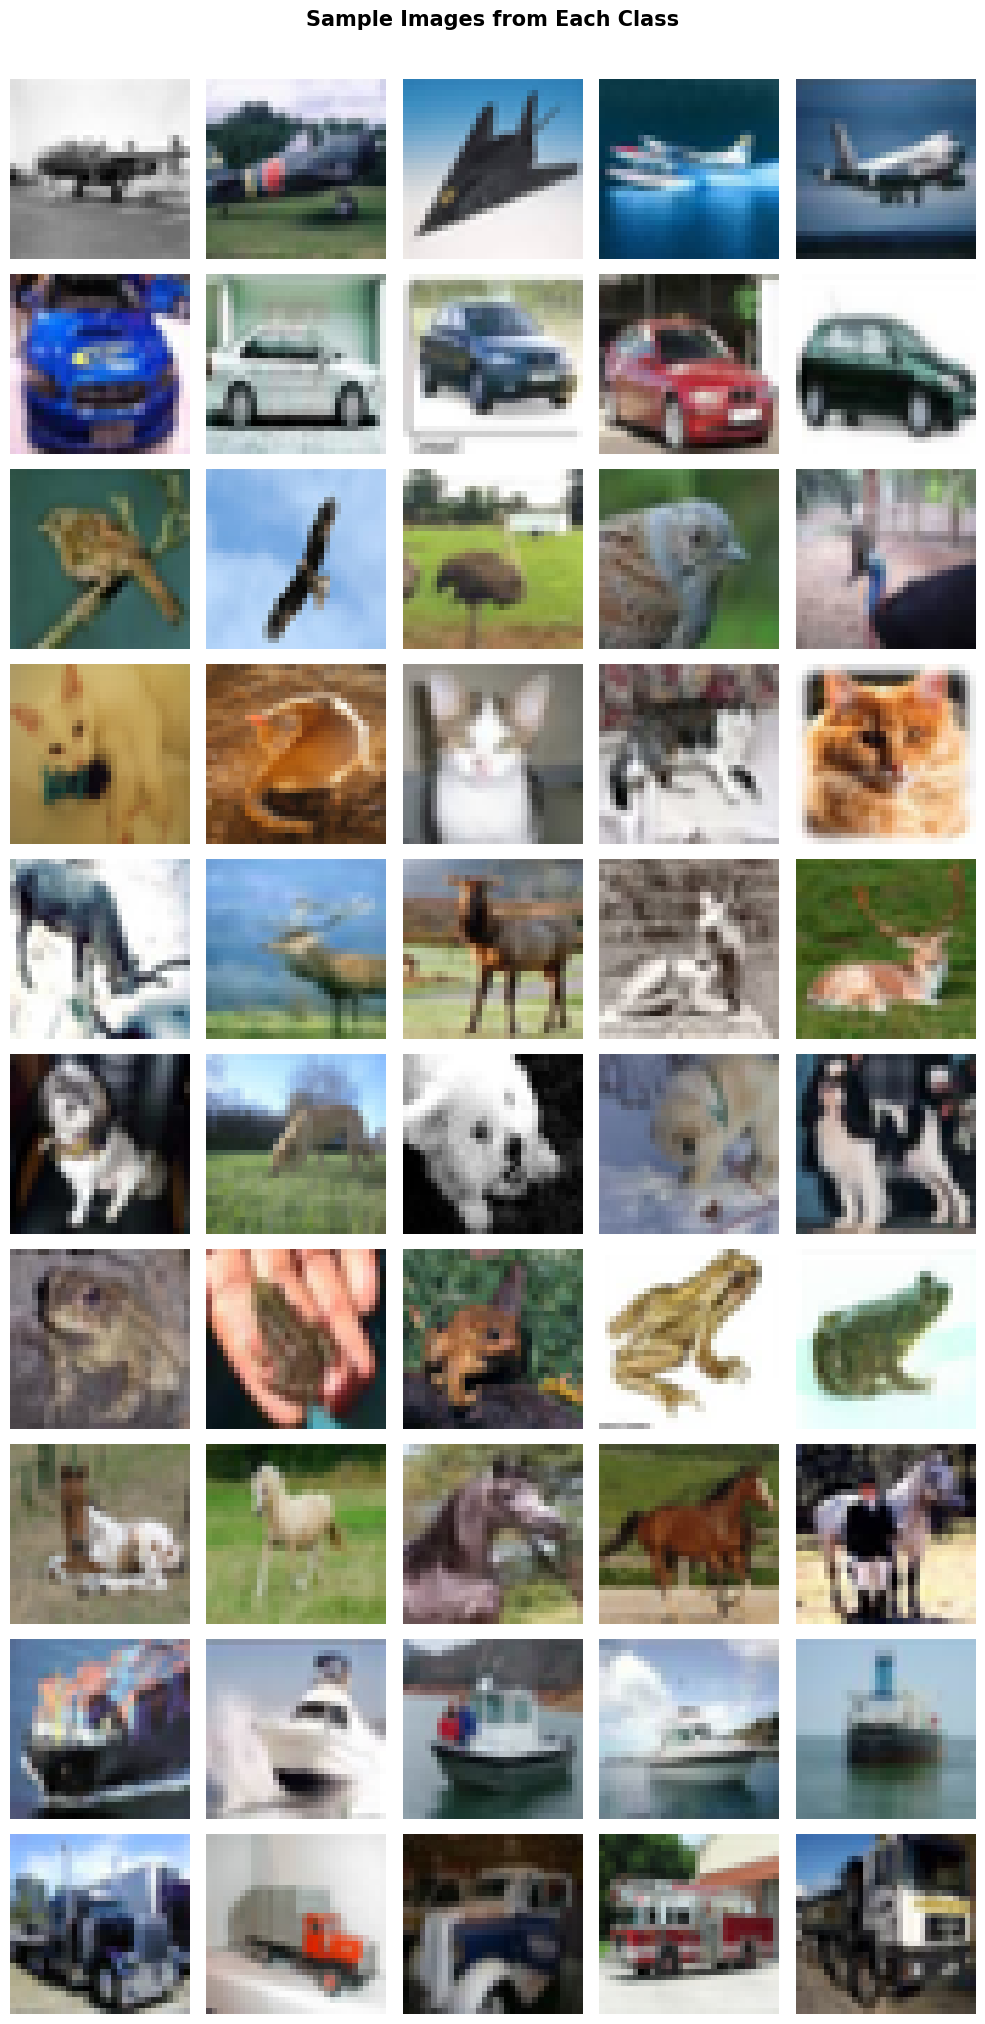

✅ Sample images displayed.


In [3]:
# ── 3.1  Show a grid of sample images ────────────────────────────────────────
# We'll show 5 random images for each of the 10 classes.

fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle("Sample Images from Each Class", fontsize=15, y=1.01, fontweight="bold")

for row, class_index in enumerate(range(NUM_CLASSES)):
    # Find all training images that belong to this class
    indices_for_class = np.where(y_train_full == class_index)[0]
    
    # Pick 5 random images from that class
    chosen_indices = np.random.choice(indices_for_class, 5, replace=False)
    
    for col, img_index in enumerate(chosen_indices):
        axes[row, col].imshow(x_train_full[img_index])   # show the image
        axes[row, col].axis("off")                        # hide axis ticks
        if col == 0:
            # Write the class name on the left side
            axes[row, col].set_ylabel(CLASS_NAMES[class_index],
                                      rotation=0, labelpad=50,
                                      fontsize=10, fontweight="bold", va="center")
            axes[row, col].set_yticks([])

plt.tight_layout()
plt.savefig("sample_images.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Sample images displayed.")


In [4]:
# ── 3.2  Check class balance ─────────────────────────────────────────────────
# "Balanced" means every class has roughly the same number of images.
# If one class has far fewer images, the model might learn to ignore it.

# Count how many training images belong to each class
train_counts = pd.Series(y_train_full).value_counts().sort_index()

print("Number of training images per class:")
print()
for i, count in enumerate(train_counts):
    bar = "█" * (count // 200)   # simple text bar chart
    print(f"  {CLASS_NAMES[i]:<12} : {count}  {bar}")

print()
print("✅ Great news — the dataset is perfectly balanced (5,000 per class)!")


Number of training images per class:

  airplane     : 5000  █████████████████████████
  automobile   : 5000  █████████████████████████
  bird         : 5000  █████████████████████████
  cat          : 5000  █████████████████████████
  deer         : 5000  █████████████████████████
  dog          : 5000  █████████████████████████
  frog         : 5000  █████████████████████████
  horse        : 5000  █████████████████████████
  ship         : 5000  █████████████████████████
  truck        : 5000  █████████████████████████

✅ Great news — the dataset is perfectly balanced (5,000 per class)!


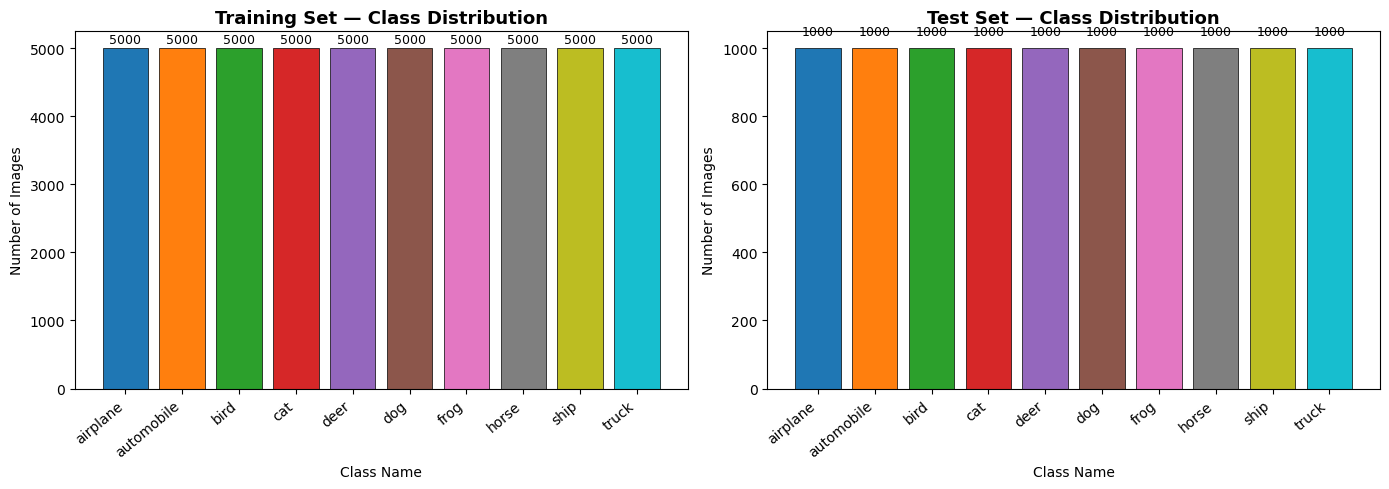

In [5]:
# ── 3.3  Draw the class distribution as a bar chart ──────────────────────────
train_counts = pd.Series(y_train_full).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ["Training Set — Class Distribution", "Test Set — Class Distribution"]
):
    colors = sns.color_palette("tab10", NUM_CLASSES)
    bars = ax.bar(CLASS_NAMES, counts.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Class Name")
    ax.set_ylabel("Number of Images")
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right")
    # Write the count on top of each bar
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30, str(count),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


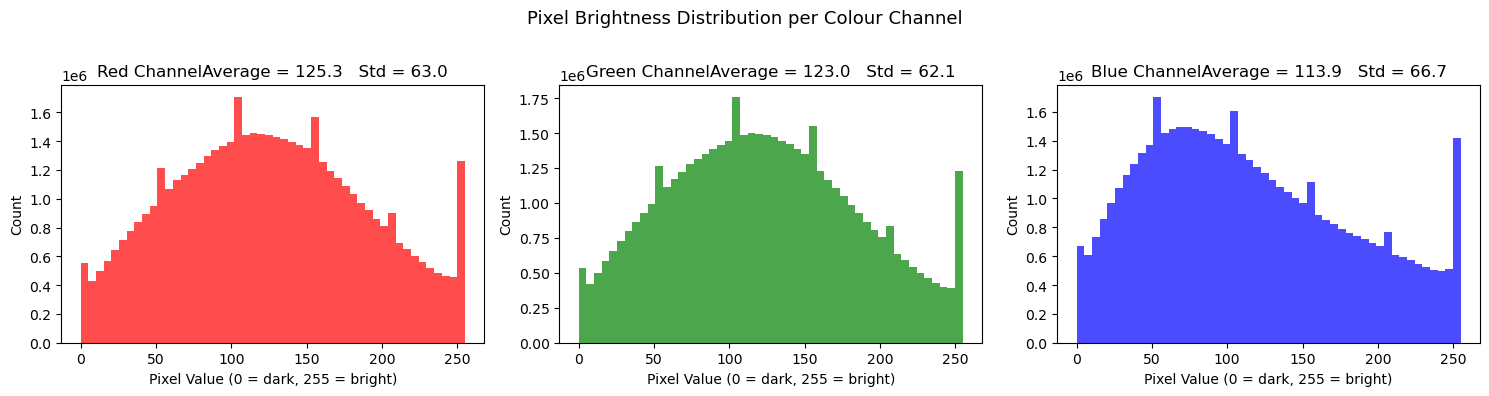

💡 Notice that all channels have similar distributions — the images are well-lit on average.


In [6]:
# ── 3.4  Look at pixel brightness distributions ───────────────────────────────
# An image has 3 colour channels: Red, Green, Blue.
# We plot how bright each channel is across all training images.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Pixel Brightness Distribution per Colour Channel", fontsize=13)

channel_names  = ["Red", "Green", "Blue"]
channel_colors = ["red", "green", "blue"]

for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    # Get all pixel values for this channel from all images
    pixel_values = x_train_full[:, :, :, i].flatten()
    
    axes[i].hist(pixel_values, bins=50, color=color, alpha=0.7, edgecolor="none")
    axes[i].set_title(f"{name} Channel"
                      f"Average = {pixel_values.mean():.1f}   Std = {pixel_values.std():.1f}")
    axes[i].set_xlabel("Pixel Value (0 = dark, 255 = bright)")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.savefig("pixel_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("💡 Notice that all channels have similar distributions — the images are well-lit on average.")


---
## Step 4 — ⚙️ Prepare the Data for Training

Before feeding images to a neural network we must do three things:

### 4a — Normalisation
Pixel values go from **0 to 255**. Neural networks learn better when numbers
are small, so we divide everything by 255 to get values between **0.0 and 1.0**.
This is called **normalisation**.

### 4b — One-hot Encoding
Labels are currently numbers like `3` (= cat).
Keras needs them as a list of 0s and 1s, e.g. `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`.
This is called **one-hot encoding**.

### 4c — Train / Validation Split
We split the 50,000 training images into:
- **Training set (80%)** — used to actually train the model
- **Validation set (20%)** — used to check how well the model is doing *during* training (but never used for the final test)

### 4d — Data Augmentation
We randomly flip, rotate, and zoom training images to create more variety.
This helps the model generalise and not just memorise the training images.


In [7]:
# ── 4a — Normalise pixel values from [0, 255] to [0.0, 1.0] ─────────────────
# We cast to float32 (decimal numbers) before dividing.
x_train_norm = x_train_full.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32")       / 255.0

print("Before normalisation — pixel range:", x_train_full.min(), "to", x_train_full.max())
print("After  normalisation — pixel range:", x_train_norm.min(), "to", x_train_norm.max())


Before normalisation — pixel range: 0 to 255
After  normalisation — pixel range: 0.0 to 1.0


In [8]:
# ── 4b — One-hot encode the labels ───────────────────────────────────────────
# Example: label 3 (cat) → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

y_train_ohe = tf.keras.utils.to_categorical(y_train_full, NUM_CLASSES)
y_test_ohe  = tf.keras.utils.to_categorical(y_test,       NUM_CLASSES)

print("Original label for first image :", y_train_full[0], f"({CLASS_NAMES[y_train_full[0]]})")
print("One-hot version                :", y_train_ohe[0])


Original label for first image : 6 (frog)
One-hot version                : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [9]:
# ── 4c — Split training data into train and validation ───────────────────────
# train_test_split randomly shuffles and splits the data.
# test_size=0.20 means 20% goes to validation.
# stratify= makes sure the split is balanced across all classes.

x_train, x_val, y_train, y_val = train_test_split(
    x_train_norm,   # images
    y_train_ohe,    # labels (one-hot)
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full   # keep class balance
)

print("Dataset split complete!")
print()
print(f"  Training   images : {x_train.shape[0]:,}   ({x_train.shape})")
print(f"  Validation images : {x_val.shape[0]:,}   ({x_val.shape})")
print(f"  Test       images : {x_test_norm.shape[0]:,}   ({x_test_norm.shape})")


Dataset split complete!

  Training   images : 40,000   ((40000, 32, 32, 3))
  Validation images : 10,000   ((10000, 32, 32, 3))
  Test       images : 10,000   ((10000, 32, 32, 3))


In [10]:
# ── 4d — Data Augmentation ───────────────────────────────────────────────────
# ImageDataGenerator applies small random changes to each image every epoch.
# The *original* image is never changed — new versions are created on-the-fly.

train_datagen = ImageDataGenerator(
    horizontal_flip  = True,   # randomly flip image left-right
    rotation_range   = 15,     # randomly rotate up to 15 degrees
    width_shift_range= 0.1,    # randomly shift image left/right by 10%
    height_shift_range=0.1,    # randomly shift image up/down by 10%
    zoom_range       = 0.1,    # randomly zoom in/out by 10%
)
train_datagen.fit(x_train)

# No augmentation for validation or test — we want a fair evaluation!
val_datagen = ImageDataGenerator()

BATCH_SIZE = 64   # process 64 images at a time during training

# Create "generators" that yield batches of images during training
train_gen = train_datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(x_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

print("✅ Data generators ready.")
print(f"   Batch size          : {BATCH_SIZE}")
print(f"   Steps per epoch     : {len(train_gen)}")


✅ Data generators ready.
   Batch size          : 64
   Steps per epoch     : 625


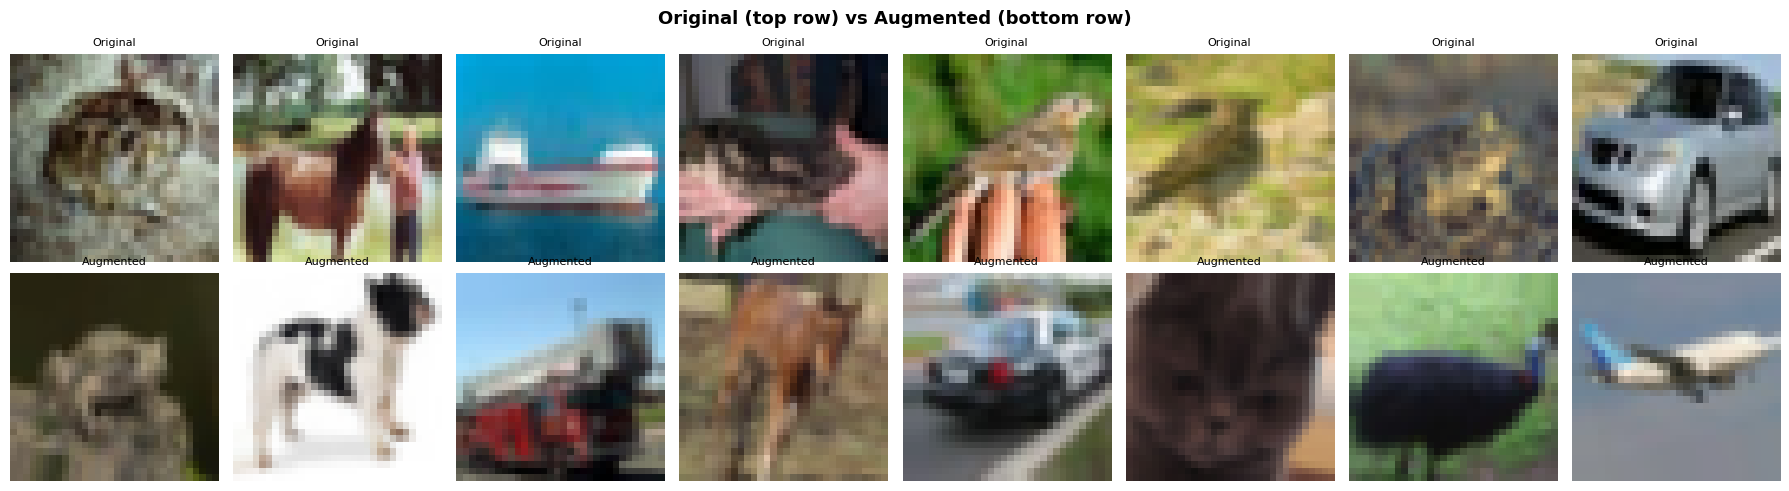

💡 Notice the subtle differences: flipped, slightly rotated or shifted images.


In [11]:
# ── 4e — Visualise augmented images ──────────────────────────────────────────
# Let's see what the augmented images look like compared to the originals.

original_imgs = x_train[:8]                    # first 8 training images
augmented_batch, _ = next(train_gen)           # first augmented batch
augmented_imgs = augmented_batch[:8]

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle("Original (top row) vs Augmented (bottom row)", fontsize=13, fontweight="bold")

for col in range(8):
    axes[0, col].imshow(np.clip(original_imgs[col], 0, 1))
    axes[0, col].axis("off")
    axes[0, col].set_title("Original", fontsize=8)

    axes[1, col].imshow(np.clip(augmented_imgs[col], 0, 1))
    axes[1, col].axis("off")
    axes[1, col].set_title("Augmented", fontsize=8)

plt.tight_layout()
plt.savefig("augmentation_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("💡 Notice the subtle differences: flipped, slightly rotated or shifted images.")


---
## Step 5 — 🏗️ Model 1: Our First CNN (Simple)

### What is a CNN?
A **Convolutional Neural Network (CNN)** is a special type of neural network
designed for images. Instead of looking at every pixel individually, it uses
small filters (like little magnifying glasses) that slide across the image and
detect patterns like edges, corners, and textures.

### Building blocks we use:
| Layer | What it does |
|---|---|
| `Conv2D` | Applies filters to detect patterns in the image |
| `BatchNormalization` | Keeps numbers stable so training is faster |
| `MaxPooling2D` | Shrinks the image (keeps the most important info) |
| `Dropout` | Randomly turns off neurons during training to prevent overfitting |
| `Dense` | A fully-connected layer for the final classification |

### What is overfitting?
Overfitting is when the model memorises the training data instead of learning
general patterns. Dropout and BatchNorm help prevent this.


In [12]:
# ── Build Model 1 — Simple CNN ───────────────────────────────────────────────
# We use Sequential API: layers are stacked one on top of another.

model_1 = models.Sequential([

    # ── BLOCK 1: Detect basic features (edges, colours) ──────────────────────
    # 32 filters, each 3×3 pixels, padding="same" keeps image size unchanged
    layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                  input_shape=(32, 32, 3), name="conv_block1_a"),
    layers.BatchNormalization(),                 # stabilise the numbers

    layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="conv_block1_b"),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),   # shrink image: 32×32 → 16×16
    layers.Dropout(0.25),          # randomly drop 25% of neurons

    # ── BLOCK 2: Detect more complex patterns ────────────────────────────────
    layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_block2_a"),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_block2_b"),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),   # shrink image: 16×16 → 8×8
    layers.Dropout(0.25),

    # ── BLOCK 3: High-level features ─────────────────────────────────────────
    layers.Conv2D(128, (3, 3), padding="same", activation="relu", name="conv_block3"),
    layers.BatchNormalization(),

    # GlobalAveragePooling replaces Flatten — it takes the average of each feature map
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),

    # ── CLASSIFIER HEAD: Decide which class the image belongs to ─────────────
    layers.Dense(256, activation="relu"),   # 256 neurons
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax"),  # 10 outputs (one per class)
    # softmax turns the numbers into probabilities that sum to 1.0

], name="SimpleCNN")

# Print a summary of the model
model_1.summary()


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block1_a (Conv2D)          │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block1_b (Conv2D)          │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2_a (Conv2D)          │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2_b (Conv2D)          │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block3 (Conv2D)            │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,298 (688.66 KB)

 Trainable params: 175,658 (686.16 KB)

 Non-trainable params: 640 (2.50 KB)

In [13]:
# ── Compile the model ────────────────────────────────────────────────────────
# Compiling tells Keras:
#   - HOW to update weights      → optimizer (Adam is a popular choice)
#   - HOW to measure error       → loss function
#   - WHAT to display during training → metrics

model_1.compile(
    optimizer="adam",                   # Adam adjusts the learning rate automatically
    loss="categorical_crossentropy",    # standard loss for multi-class classification
    metrics=["accuracy"]                # show accuracy during training
)

# ── Set up Callbacks ──────────────────────────────────────────────────────────
# Callbacks are helper functions that run after each epoch.

# EarlyStopping: stop training if val_accuracy hasn't improved for 10 epochs
# → saves time and prevents overfitting
early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",   # watch validation accuracy
    patience=10,              # wait 10 epochs before stopping
    restore_best_weights=True,# go back to the best weights found
    verbose=1
)

# ReduceLROnPlateau: lower the learning rate when training gets stuck
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,         # multiply learning rate by 0.5
    patience=4,         # wait 4 epochs before reducing
    min_lr=1e-6,        # don't go below this learning rate
    verbose=1
)

# ModelCheckpoint: save the model every time validation accuracy improves
checkpoint_1 = callbacks.ModelCheckpoint(
    "best_model_1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("✅ Model 1 compiled and callbacks ready.")


✅ Model 1 compiled and callbacks ready.


In [15]:
# ── Train Model 1 ────────────────────────────────────────────────────────────
# model.fit() is where the actual learning happens.
# Each "epoch" = one full pass through all training images.

print("🚀 Starting training for Model 1 (SimpleCNN)...")
print("   This may take a few minutes. Watch the accuracy go up!")
print()

EPOCHS =30  # maximum number of epochs (EarlyStopping may stop it sooner)

history_1 = model_1.fit(
    train_gen,                               # augmented training images
    epochs=EPOCHS,
    validation_data=val_gen,                 # used to check performance each epoch
    callbacks=[early_stop, reduce_lr, checkpoint_1],
    verbose=1
)

print()
print("✅ Model 1 training finished!")


🚀 Starting training for Model 1 (SimpleCNN)...
   This may take a few minutes. Watch the accuracy go up!

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5791 - loss: 1.1789
Epoch 1: val_accuracy improved from 0.51420 to 0.55590, saving model to best_model_1.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.5791 - loss: 1.1789 - val_accuracy: 0.5559 - val_loss: 1.3728 - learning_rate: 0.0010
Epoch 2/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6192 - loss: 1.0783
Epoch 2: val_accuracy improved from 0.55590 to 0.64440, saving model to best_model_1.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.6193 - loss: 1.0782 - val_accuracy: 0.6444 - val_loss: 1.0507 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6494 - loss: 1.0044
Epoch 3: val_accuracy did not improve from 0.64440
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.6494 - loss: 1.0044 - val_accuracy: 0.6362 - val_loss: 1.

---
## Step 6 — 🏗️ Model 2: A Deeper CNN with Skip Connections

Our second model is more powerful. It uses **skip connections** (also called
residual connections): the input of a block is added back to its output.

**Why does this help?**
In very deep networks, the signal can get weak as it travels through many layers.
Skip connections create a shortcut so the signal always reaches every layer clearly.
This is the core idea behind Microsoft's famous **ResNet** architecture.

```
Input ──→ [Conv → BN → ReLU → Conv → BN] ──→ + ──→ Output
   ╰──────────────────────────────────────────╯
               (shortcut / skip connection)
```


In [16]:
# ── Helper function: one residual block ──────────────────────────────────────
# A function so we can reuse this block multiple times without repeating code.

def residual_block(x, num_filters, downsample=False):
    """
    One residual block.

    x           : input tensor (the image features at this stage)
    num_filters : how many convolutional filters to use
    downsample  : if True, shrink the spatial size by half (stride=2)
    """
    stride = 2 if downsample else 1
    shortcut = x    # save the input so we can add it back later

    # ── Main path (two convolutions) ─────────────────────────────────────────
    y = layers.Conv2D(num_filters, (3, 3), strides=stride, padding="same")(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)

    y = layers.Conv2D(num_filters, (3, 3), padding="same")(y)
    y = layers.BatchNormalization()(y)

    # ── Shortcut path ─────────────────────────────────────────────────────────
    # If we changed the size (downsample) or the number of filters,
    # we need to adjust the shortcut so both paths have the same shape.
    if downsample or x.shape[-1] != num_filters:
        shortcut = layers.Conv2D(num_filters, (1, 1), strides=stride, padding="same")(x)
        shortcut = layers.BatchNormalization()(shortcut)

    # ── Add the two paths together ────────────────────────────────────────────
    y = layers.Add()([y, shortcut])   # element-wise addition
    y = layers.Activation("relu")(y)
    return y


# ── Build the deep CNN ────────────────────────────────────────────────────────
def build_deep_cnn(input_shape=(32, 32, 3), num_classes=10):
    """Builds a deeper CNN with 4 pairs of residual blocks."""
    inputs = keras.Input(shape=input_shape)

    # ── Stem: first convolution to extract initial features ───────────────────
    x = layers.Conv2D(64, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # ── Residual blocks (progressively more filters, smaller spatial size) ────
    x = residual_block(x, 64)             # 32×32, 64 filters
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)   # 16×16, 128 filters
    x = residual_block(x, 128)
    x = residual_block(x, 256, downsample=True)   # 8×8, 256 filters
    x = residual_block(x, 256)

    # ── Classifier head ───────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="DeepCNN_Residual")


model_2 = build_deep_cnn()
model_2.summary()


Model: "DeepCNN_Residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 2,918,538 (11.13 MB)

 Trainable params: 2,914,058 (11.12 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [17]:
# ── Compile & Train Model 2 ──────────────────────────────────────────────────
model_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_2 = callbacks.ModelCheckpoint(
    "best_model_2.keras", monitor="val_accuracy", save_best_only=True, verbose=1
)

print("🚀 Training Model 2 (DeepCNN with skip connections)...")
print()

history_2 = model_2.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr, checkpoint_2],
    verbose=1
)

print()
print("✅ Model 2 training finished!")


🚀 Training Model 2 (DeepCNN with skip connections)...

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.2769 - loss: 1.9768
Epoch 1: val_accuracy improved from -inf to 0.44750, saving model to best_model_2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 345s 534ms/step - accuracy: 0.2770 - loss: 1.9764 - val_accuracy: 0.4475 - val_loss: 1.5711 - learning_rate: 0.0010
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.4938 - loss: 1.3816
Epoch 2: val_accuracy improved from 0.44750 to 0.48360, saving model to best_model_2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 412ms/step - accuracy: 0.4938 - loss: 1.3815 - val_accuracy: 0.4836 - val_loss: 1.6266 - learning_rate: 0.0010
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5803 - loss: 1.1740
Epoch 3: val_accuracy improved from 0.48360 to 0.50400, saving model to best_model_2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 268s 428ms/step - accuracy: 0.5803 - loss: 1.1739 - val_accuracy: 0.5040 - val_loss: 1.7391 

---
## Step 7 — 🔄 Model 3: Transfer Learning with MobileNetV2

### What is Transfer Learning?
Imagine you already know how to ride a bicycle.
Learning to ride a motorbike is much easier because many skills transfer over.

Similarly, **MobileNetV2** was trained on **ImageNet** — over 1 million images
from 1,000 categories. It already knows how to detect edges, shapes, textures,
eyes, wheels, etc.

We **re-use** those learned features and add a small new "head" on top
to classify our 10 CIFAR-10 classes.

### Training in two phases:
1. **Phase 1 — Freeze the base:** Only train the new head (fast ⚡)
2. **Phase 2 — Fine-tune:** Unfreeze the last few layers and train at a very low learning rate (slow but more accurate 🎯)

> **Note:** MobileNetV2 needs images at least 32×32.  
> We resize our images to **96×96** to give it more detail to work with.


In [19]:
# ── Resize images from 32×32 to 96×96 for transfer learning ──────────────────
# Larger images carry more detail → better accuracy for the pre-trained model.
# tf.image.resize handles the resizing efficiently.

TARGET_SIZE = 96    # new image size (height and width)

print(f"Resizing images to {TARGET_SIZE}×{TARGET_SIZE} ... (may take ~30 seconds)")

# resize returns a TensorFlow tensor, .numpy() converts it to a numpy array
x_train_96   = tf.image.resize(x_train,      [TARGET_SIZE, TARGET_SIZE]).numpy()
x_val_96     = tf.image.resize(x_val,        [TARGET_SIZE, TARGET_SIZE]).numpy()
x_test_96    = tf.image.resize(x_test_norm,  [TARGET_SIZE, TARGET_SIZE]).numpy()

print(f"✅ Done!  New shape: {x_train_96.shape}")

# Create new generators for the resized images
train_gen_96 = train_datagen.flow(x_train_96, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen_96   = val_datagen.flow(x_val_96,    y_val,   batch_size=BATCH_SIZE, shuffle=False)

Resizing images to 96×96 ... (may take ~30 seconds)
✅ Done!  New shape: (40000, 96, 96, 3)


In [20]:
# ── Build MobileNetV2 model ───────────────────────────────────────────────────
input_shape_96 = (TARGET_SIZE, TARGET_SIZE, 3)

# Load MobileNetV2 WITHOUT its top classification layers (include_top=False)
# weights="imagenet" → use weights already learned from ImageNet
base_mnv2 = MobileNetV2(input_shape=input_shape_96, include_top=False, weights="imagenet")
base_mnv2.trainable = False   # freeze: don't change the pre-trained weights yet

# Build our model on top
inputs  = keras.Input(shape=input_shape_96)
x       = base_mnv2(inputs, training=False)   # pass images through the frozen base
x       = layers.GlobalAveragePooling2D()(x)  # compress feature maps to a vector
x       = layers.Dense(256, activation="relu")(x)   # our new layer
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)   # 10-class output

model_3 = keras.Model(inputs, outputs, name="MobileNetV2_TransferLearning")
model_3.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 20s 2us/step


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
# ── Phase 1: Train only the new head (base is frozen) ────────────────────────
print("📌 Phase 1: Training only the classification head (base frozen)...")
print()

model_3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

checkpoint_3 = callbacks.ModelCheckpoint(
    "best_model_3.keras", monitor="val_accuracy", save_best_only=True, verbose=1
)

history_3a = model_3.fit(
    train_gen_96,
    epochs=20,
    validation_data=val_gen_96,
    callbacks=[reduce_lr, checkpoint_3],
    verbose=1
)

# ── Phase 2: Fine-tune the last 30 layers of MobileNetV2 ─────────────────────
print()
print("🔓 Phase 2: Unfreezing last 30 layers for fine-tuning...")
print()

base_mnv2.trainable = True

# Keep all layers except the last 30 frozen
for layer in base_mnv2.layers[:-30]:
    layer.trainable = False

# Use a MUCH smaller learning rate so we don't destroy the pre-trained weights
model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_3b = model_3.fit(
    train_gen_96,
    epochs=20,
    validation_data=val_gen_96,
    callbacks=[early_stop, reduce_lr, checkpoint_3],
    verbose=1
)

# Combine both training phases for one history
def combine_histories(h1, h2):
    """Merge two Keras history objects into one dictionary."""
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history_3 = combine_histories(history_3a, history_3b)
print()
print("✅ MobileNetV2 training complete!")

📌 Phase 1: Training only the classification head (base frozen)...

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5712 - loss: 1.2646
Epoch 1: val_accuracy improved from -inf to 0.76000, saving model to best_model_3.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 193ms/step - accuracy: 0.5713 - loss: 1.2642 - val_accuracy: 0.7600 - val_loss: 0.6702 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7013 - loss: 0.8497
Epoch 2: val_accuracy improved from 0.76000 to 0.77160, saving model to best_model_3.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 172ms/step - accuracy: 0.7013 - loss: 0.8497 - val_accuracy: 0.7716 - val_loss: 0.6569 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7168 - loss: 0.8065
Epoch 3: val_accuracy improved from 0.77160 to 0.78830, saving model to best_model_3.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.7168 - loss: 0.8065 - val_accuracy: 0.7883 - val_l

---
## Step 8 — 🔄 Model 4: Transfer Learning with VGG16

**VGG16** is a deeper, classic architecture from Oxford (2014).
It has 16 weight layers and is known for its simplicity and strong performance.

We use the same two-phase strategy as MobileNetV2.

| | MobileNetV2 | VGG16 |
|---|---|---|
| Parameters | ~3.4 M | ~138 M |
| Speed | Very fast | Slower |
| Accuracy | High | Very high |
| Best for | Mobile devices | Desktop/server |


In [22]:
# ── Build VGG16 model ─────────────────────────────────────────────────────────
base_vgg = VGG16(input_shape=input_shape_96, include_top=False, weights="imagenet")
base_vgg.trainable = False   # freeze during Phase 1

inputs  = keras.Input(shape=input_shape_96)
x       = base_vgg(inputs, training=False)
x       = layers.Flatten()(x)                         # VGG16 uses Flatten (not GlobalAvgPool)
x       = layers.Dense(512, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model_4 = keras.Model(inputs, outputs, name="VGG16_TransferLearning")
model_4.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 38s 1us/step


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,208,394 (65.64 MB)

 Trainable params: 2,493,706 (9.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [23]:
# ── Phase 1: Train only the head ─────────────────────────────────────────────
print("📌 Phase 1: Training VGG16 head (base frozen)...")
print()

model_4.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

checkpoint_4 = callbacks.ModelCheckpoint(
    "best_model_4.keras", monitor="val_accuracy", save_best_only=True, verbose=1
)

history_4a = model_4.fit(
    train_gen_96,
    epochs=15,
    validation_data=val_gen_96,
    callbacks=[reduce_lr, checkpoint_4],
    verbose=1
)

# ── Phase 2: Fine-tune last 4 conv layers ─────────────────────────────────────
print()
print("🔓 Phase 2: Unfreezing last 4 layers for fine-tuning...")
print()

base_vgg.trainable = True
for layer in base_vgg.layers[:-4]:
    layer.trainable = False

model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_4b = model_4.fit(
    train_gen_96,
    epochs=15,
    validation_data=val_gen_96,
    callbacks=[early_stop, reduce_lr, checkpoint_4],
    verbose=1
)

history_4 = combine_histories(history_4a, history_4b)
print()
print("✅ VGG16 training complete!")


📌 Phase 1: Training VGG16 head (base frozen)...

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.4199 - loss: 1.6398
Epoch 1: val_accuracy improved from -inf to 0.66560, saving model to best_model_4.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 402s 641ms/step - accuracy: 0.4201 - loss: 1.6394 - val_accuracy: 0.6656 - val_loss: 0.9970 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.5829 - loss: 1.2090
Epoch 2: val_accuracy improved from 0.66560 to 0.68460, saving model to best_model_4.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 395s 632ms/step - accuracy: 0.5829 - loss: 1.2089 - val_accuracy: 0.6846 - val_loss: 0.9098 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.6219 - loss: 1.1031
Epoch 3: val_accuracy improved from 0.68460 to 0.70030, saving model to best_model_4.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 389s 622ms/step - accuracy: 0.6219 - loss: 1.1031 - val_accuracy: 0.7003 - val_loss: 0.8681 - lear

---
## Step 9 — 📈 Plot Training History

After training, we look at two curves for each model:

- **Accuracy curve**: how often did the model guess correctly?
  - Training accuracy should go up over time.
  - If validation accuracy stops going up but training accuracy keeps rising → **overfitting**!

- **Loss curve**: how wrong was the model on average?
  - Both curves should go down over time.
  - A large gap between train and val loss = overfitting.


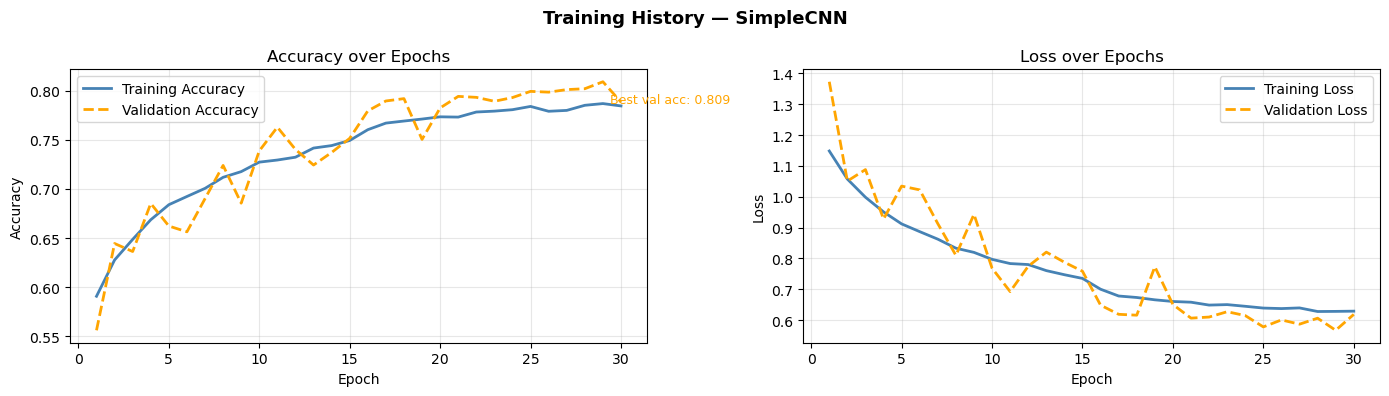

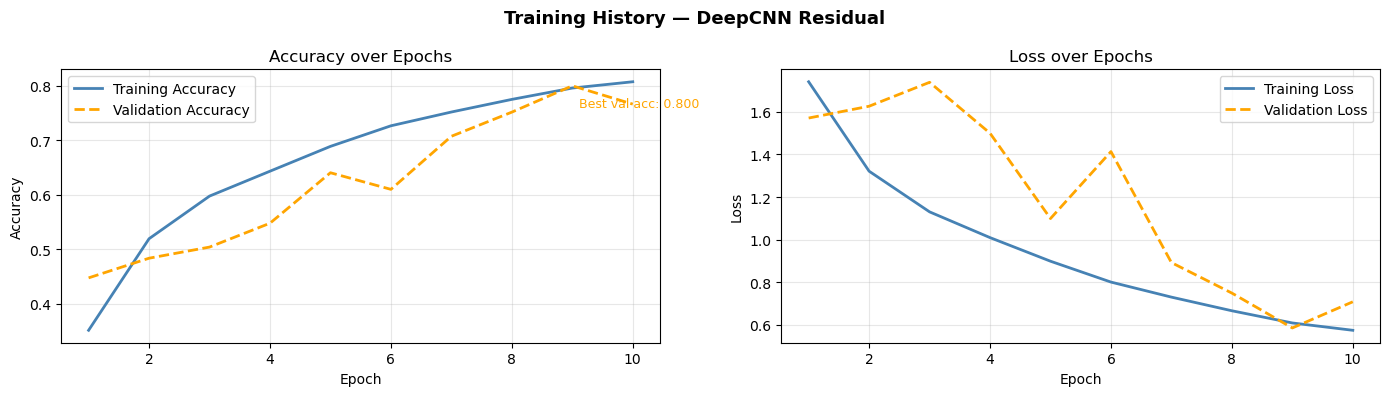

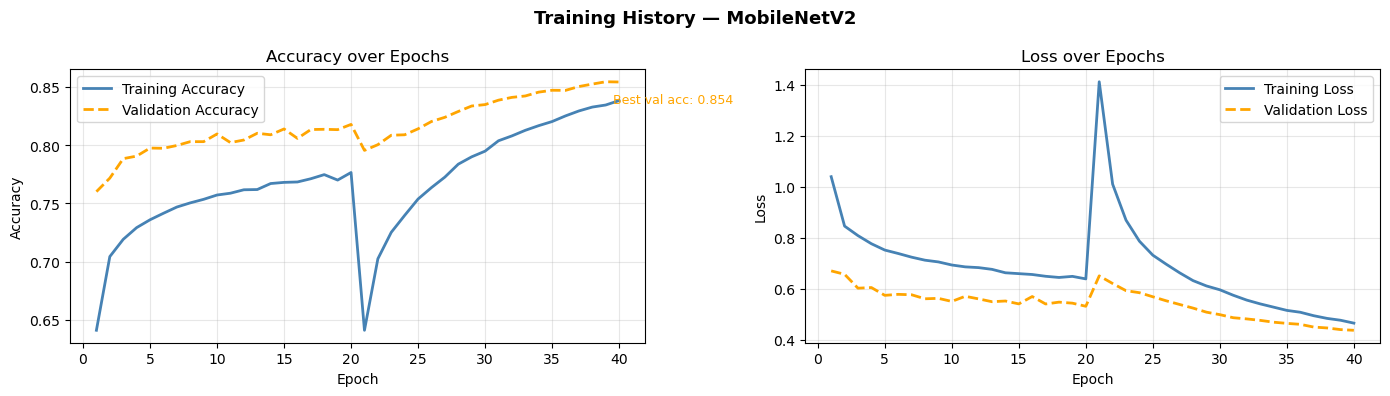

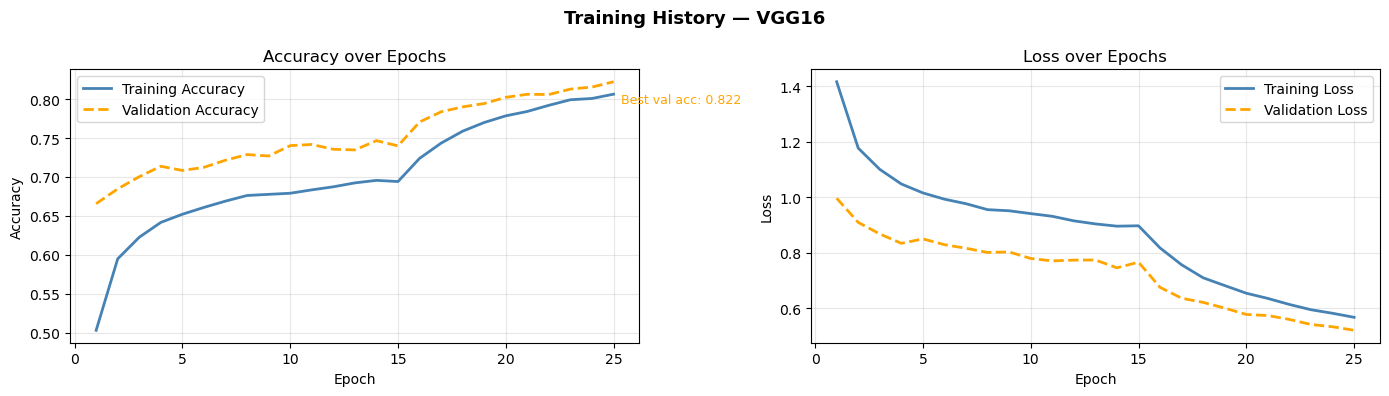

In [24]:
# ── Helper function to draw accuracy + loss curves ───────────────────────────
def plot_training_history(history_dict, model_name):
    """
    Draw accuracy and loss curves for one model.

    history_dict : dict with keys 'accuracy', 'val_accuracy', 'loss', 'val_loss'
    model_name   : string used in the plot title
    """
    acc      = history_dict["accuracy"]
    val_acc  = history_dict["val_accuracy"]
    loss     = history_dict["loss"]
    val_loss = history_dict["val_loss"]
    epochs   = range(1, len(acc) + 1)

    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Training History — {model_name}", fontsize=13, fontweight="bold")

    # ── Accuracy ──────────────────────────────────────────────────────────────
    ax_acc.plot(epochs, acc,     label="Training Accuracy",   linewidth=2, color="steelblue")
    ax_acc.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2, color="orange",
                linestyle="--")
    ax_acc.set_title("Accuracy over Epochs")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)
    ax_acc.annotate(f"Best val acc: {max(val_acc):.3f}",
                    xy=(val_acc.index(max(val_acc)) + 1, max(val_acc)),
                    xytext=(5, -15), textcoords="offset points",
                    fontsize=9, color="orange")

    # ── Loss ──────────────────────────────────────────────────────────────────
    ax_loss.plot(epochs, loss,     label="Training Loss",   linewidth=2, color="steelblue")
    ax_loss.plot(epochs, val_loss, label="Validation Loss", linewidth=2, color="orange",
                 linestyle="--")
    ax_loss.set_title("Loss over Epochs")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    plt.tight_layout()
    fname = f"history_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()


# ── Plot all 4 models ─────────────────────────────────────────────────────────
model_names_list   = ["SimpleCNN", "DeepCNN Residual", "MobileNetV2", "VGG16"]
all_histories_list = [history_1.history, history_2.history, history_3, history_4]

for name, hist in zip(model_names_list, all_histories_list):
    plot_training_history(hist, name)

In [25]:
TARGET_SIZE = 96

test_ds_96 = tf.data.Dataset.from_tensor_slices((x_test_norm, y_test))

test_ds_96 = test_ds_96.map(
    lambda x, y: (tf.image.resize(x, (TARGET_SIZE, TARGET_SIZE)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds_96 = test_ds_96.batch(64).prefetch(tf.data.AUTOTUNE)

---
## Step 10 — 🎯 Evaluate All Models on the Test Set

Now we test each model on the **test set** — images the model has **never seen** before.

### Evaluation tools we use:

**Confusion Matrix**
- A grid where each row = the true class and each column = what the model predicted.
- Numbers on the diagonal = correct predictions ✅
- Numbers off the diagonal = mistakes ❌

**Classification Report**
| Metric | Meaning |
|---|---|
| Precision | Of all the times the model said "cat", how often was it right? |
| Recall | Of all the actual cats, how many did the model find? |
| F1-Score | Balanced average of Precision and Recall |
| Accuracy | Overall % of correct predictions |


  Results for: SimpleCNN
  Test Loss     : 0.5829
  Test Accuracy : 80.17%

  Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.78      0.83      1000
  automobile       0.89      0.93      0.91      1000
        bird       0.83      0.64      0.72      1000
         cat       0.68      0.68      0.68      1000
        deer       0.75      0.83      0.78      1000
         dog       0.89      0.55      0.68      1000
        frog       0.61      0.96      0.75      1000
       horse       0.89      0.82      0.85      1000
        ship       0.88      0.92      0.90      1000
       truck       0.88      0.90      0.89      1000

    accuracy                           0.80     10000
   macro avg       0.82      0.80      0.80     10000
weighted avg       0.82      0.80      0.80     10000



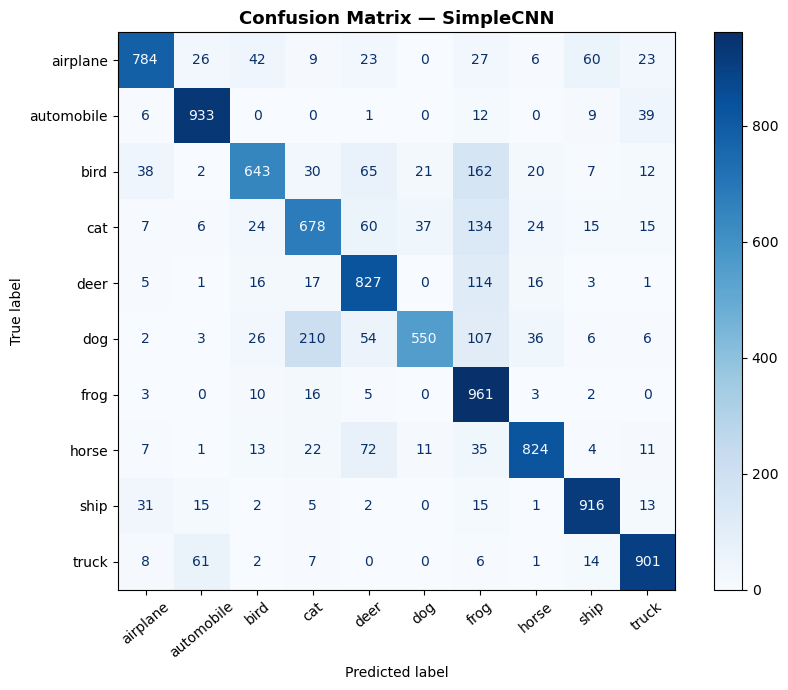

In [26]:
# ── Helper function: evaluate one model ───────────────────────────────────────
def evaluate_model(model, x_data, y_true_integers, model_name):
    """
    Tests a model and prints its results.

    model            : the trained Keras model
    x_data           : images (numpy array, already normalised)
    y_true_integers  : true labels as integers (e.g. [3, 7, 1, ...])
    model_name       : string for the title
    """
    # Convert integer labels to one-hot for loss calculation
    y_ohe = tf.keras.utils.to_categorical(y_true_integers, NUM_CLASSES)

    # Get loss and accuracy on the test set
    loss, accuracy = model.evaluate(x_data, y_ohe, batch_size=64, verbose=0)

    # Get predictions (probabilities for each class)
    predictions_prob = model.predict(x_data, batch_size=64, verbose=0)

    # Pick the class with the highest probability
    predictions_int  = np.argmax(predictions_prob, axis=1)

    # ── Print results ─────────────────────────────────────────────────────────
    print("=" * 60)
    print(f"  Results for: {model_name}")
    print("=" * 60)
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {accuracy*100:.2f}%")
    print()
    print("  Classification Report:")
    print(classification_report(y_true_integers, predictions_int, target_names=CLASS_NAMES))

    # ── Confusion Matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(y_true_integers, predictions_int)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=40)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name.replace(' ', '_')}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

    return accuracy, predictions_int


# ── Evaluate all 4 models ─────────────────────────────────────────────────────
# NOTE: Models 1 & 2 were trained on 32×32 images.
#       Models 3 & 4 were trained on 96×96 images.

all_results = {}    # store results here for comparison later

acc1, _ = evaluate_model(model_1, x_test_norm, y_test, "SimpleCNN")
all_results["SimpleCNN"]      = acc1

# acc2, _ = evaluate_model(model_2, x_test_norm, y_test, "DeepCNN Residual")
# all_results["DeepCNN Residual"] = acc2

# acc3, _ = evaluate_model(model_3, test_ds_96,y_test, "MobileNetV2")
# all_results["MobileNetV2"]    = acc3

# acc4, _ = evaluate_model(model_4, x_test_96,   y_test, "VGG16")
# all_results["VGG16"]          = acc4


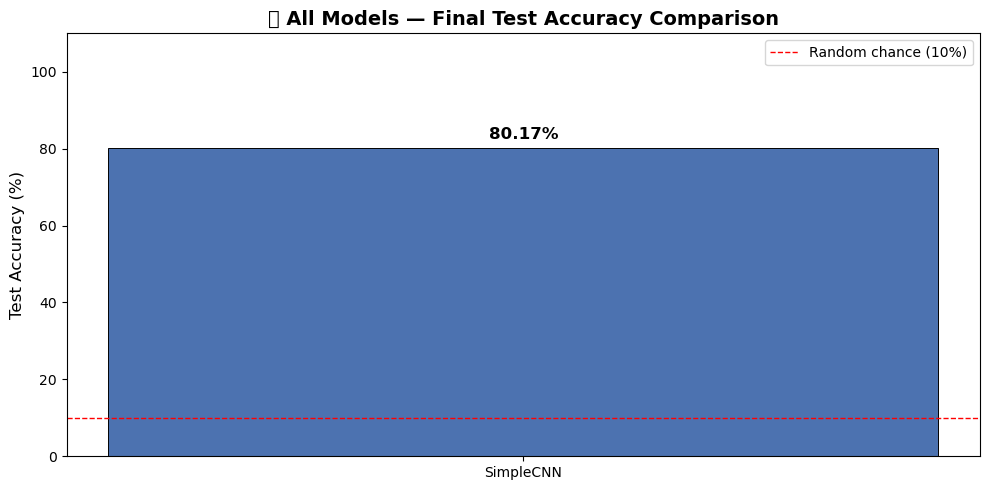


Final Test Accuracies (sorted best → worst):
  SimpleCNN              80.17%  ⭐⭐⭐⭐


In [27]:
# ── Summary comparison chart ──────────────────────────────────────────────────
model_labels = list(all_results.keys())
accuracies   = [all_results[m] * 100 for m in model_labels]
bar_colors   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_labels, accuracies, color=bar_colors, edgecolor="black", linewidth=0.7, width=0.5)

ax.set_ylim(0, 110)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("📊 All Models — Final Test Accuracy Comparison", fontsize=14, fontweight="bold")
ax.axhline(y=10, color="red", linestyle="--", linewidth=1, label="Random chance (10%)")
ax.legend()

# Write the accuracy % on top of each bar
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{acc:.2f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print()
print("Final Test Accuracies (sorted best → worst):")
for name, acc in sorted(all_results.items(), key=lambda item: -item[1]):
    stars = "⭐" * round(acc * 5)
    print(f"  {name:<22} {acc*100:.2f}%  {stars}")


---
## Step 11 — 🚀 Best Model & Inference Pipeline

### What is an Inference Pipeline?
After training, we want to use our model on **new, unseen images**.
An inference pipeline is a function that:

1. Takes a raw image as input
2. Resizes and normalises it (same preprocessing we did for training)
3. Feeds it through the model
4. Returns the predicted class name and confidence %

This is exactly what would run in a real-world application!


In [29]:
# ── Automatically pick the best model ────────────────────────────────────────
best_model_name = max(all_results, key=all_results.get)
best_accuracy   = all_results[best_model_name]

print(f"🏆 Best model : {best_model_name}")
print(f"   Test accuracy : {best_accuracy*100:.2f}%")

# Map each model name to (model object, expected image size)
model_registry = {
    "SimpleCNN"       : (model_1, 32),
    "DeepCNN Residual": (model_2, 32),
    "MobileNetV2"     : (model_3, 96),
    "VGG16"           : (model_4, 96),
}

best_model, best_img_size = model_registry[best_model_name]
print(f"   Input image size : {best_img_size}×{best_img_size} pixels")


🏆 Best model : SimpleCNN
   Test accuracy : 80.17%
   Input image size : 32×32 pixels


In [30]:
from pandas._config import config
from pandas._config import config
# ── The Inference Pipeline function ──────────────────────────────────────────
def predict_single_image(image_array, model, img_size, class_names):
    """
    Predict the class of a single image.

    image_array  : numpy array of shape (H, W, 3), pixel values 0-255 or 0-1
    model        : trained Keras model
    img_size     : expected spatial size (e.g. 32 or 96)
    class_names  : list of class label strings

    Returns a dictionary with the prediction details.
    """
    # ── Step 1: Normalise (make sure pixels are in [0, 1]) ───────────────────
    img_float = image_array.astype("float32")
    if img_float.max() > 1.0:          # if pixel values are 0-255
        img_float = img_float / 255.0  # normalise to 0-1

    # ── Step 2: Resize to the size the model expects ─────────────────────────
    img_resized = tf.image.resize(img_float, [img_size, img_size]).numpy()

    # ── Step 3: Add a "batch" dimension (model expects shape [1, H, W, 3]) ───
    img_batch = np.expand_dims(img_resized, axis=0)

    # ── Step 4: Get predictions ───────────────────────────────────────────────
    probabilities = model.predict(img_batch, verbose=0)[0]   # array of 10 probabilities
    predicted_idx = int(np.argmax(probabilities))             # index of highest probability
    predicted_class = class_names[predicted_idx]
    confidence = float(probabilities[predicted_idx])

    # ── Step 5: Visualise ─────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4))

    # Show the image
    ax_img.imshow(np.clip(img_resized, 0, 1))
    ax_img.set_title(
        f"Prediction: {predicted_class.upper()}Confidence: {confidence*100:.1f}%",
        fontsize=13, fontweight="bold",
        color="green" if confidence > 0.6 else "orange"
    )
    ax_img.axis("off")

    # Horizontal bar chart of all class probabilities
    bar_colors = [
        "#2ECC71" if i == predicted_idx else "#AED6F1"
        for i in range(len(class_names))
    ]
    ax_bar.barh(class_names, probabilities * 100, color=bar_colors, edgecolor="gray", linewidth=0.5)
    ax_bar.set_xlabel("Probability (%)")
    ax_bar.set_title("All Class Probabilities")
    ax_bar.set_xlim(0, 110)
    for i, prob in enumerate(probabilities * 100):
        ax_bar.text(prob + 0.5, i, f"{prob:.1f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return {
        "predicted_class"   : predicted_class,
        "confidence_pct"    : round(confidence * 100, 2),
        "all_probabilities" : dict(zip(class_names, [round(float(p)*100, 2) for p in probabilities]))
    }

print("✅ Inference pipeline ready!")


✅ Inference pipeline ready!


🔍 Running inference with [SimpleCNN] on 6 random test images:



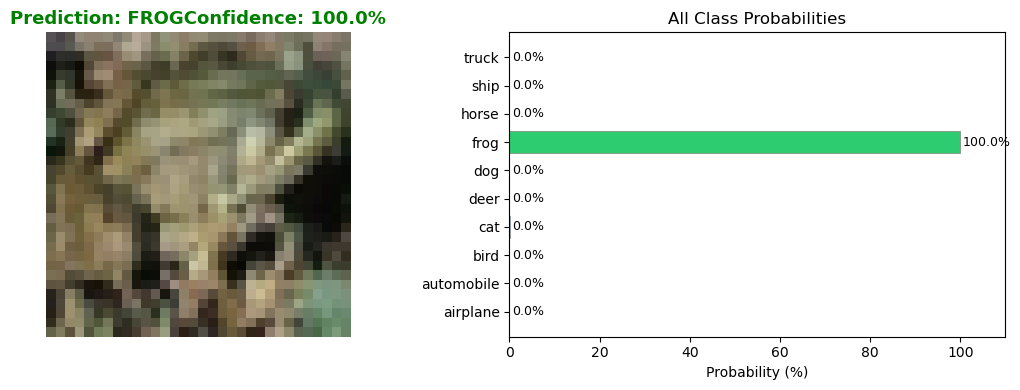

  True label : frog          Predicted : frog          Confidence : 100.0%  ✅


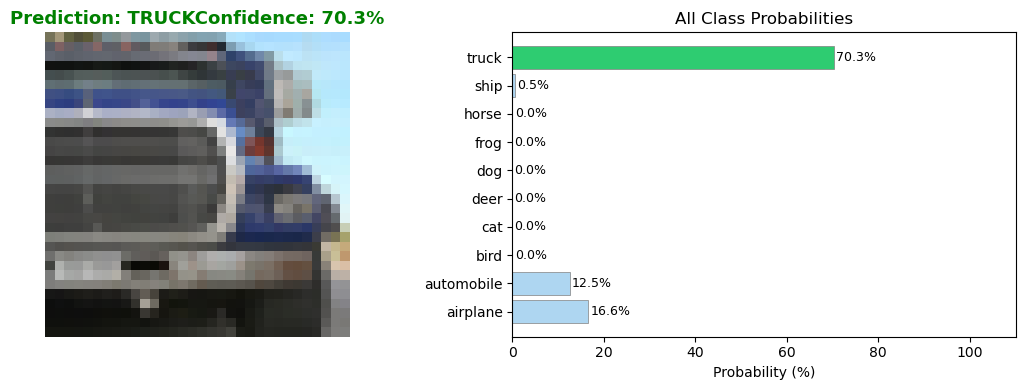

  True label : truck         Predicted : truck         Confidence : 70.3%  ✅


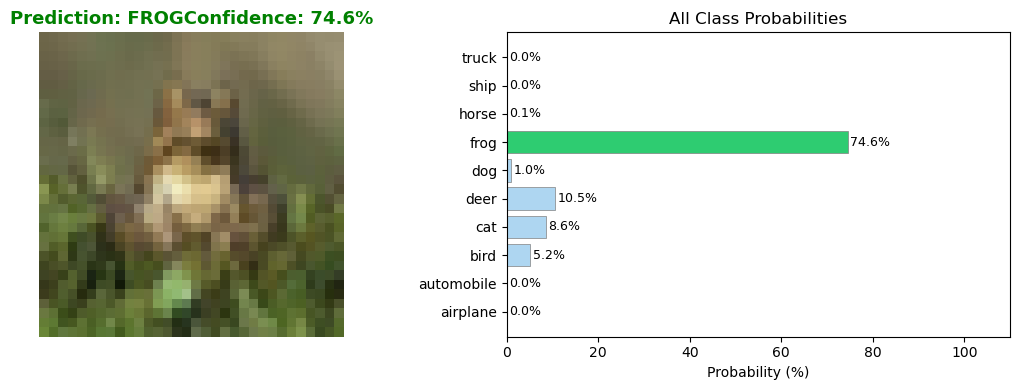

  True label : frog          Predicted : frog          Confidence : 74.6%  ✅


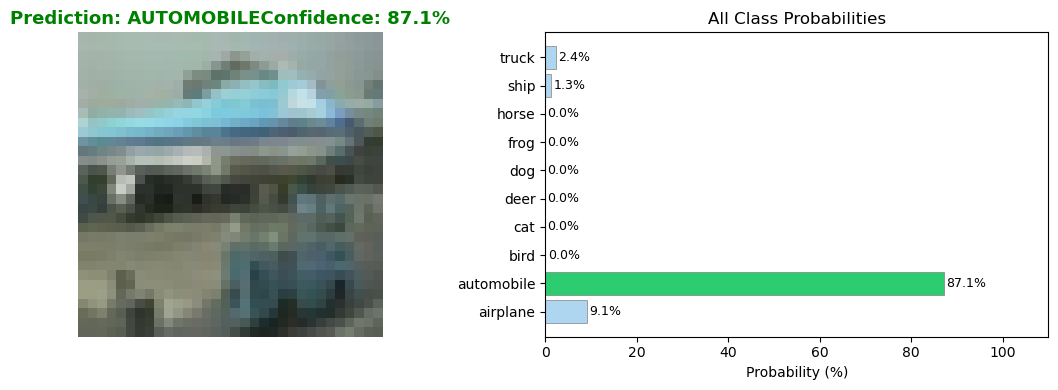

  True label : airplane      Predicted : automobile    Confidence : 87.1%  ❌


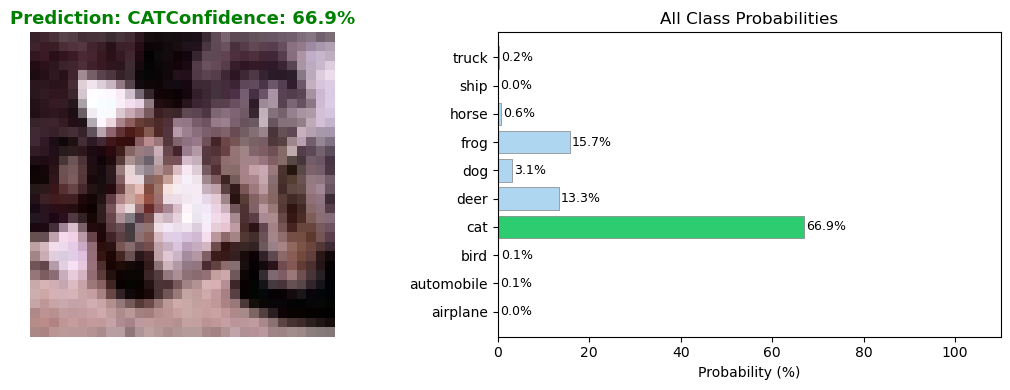

  True label : cat           Predicted : cat           Confidence : 66.9%  ✅


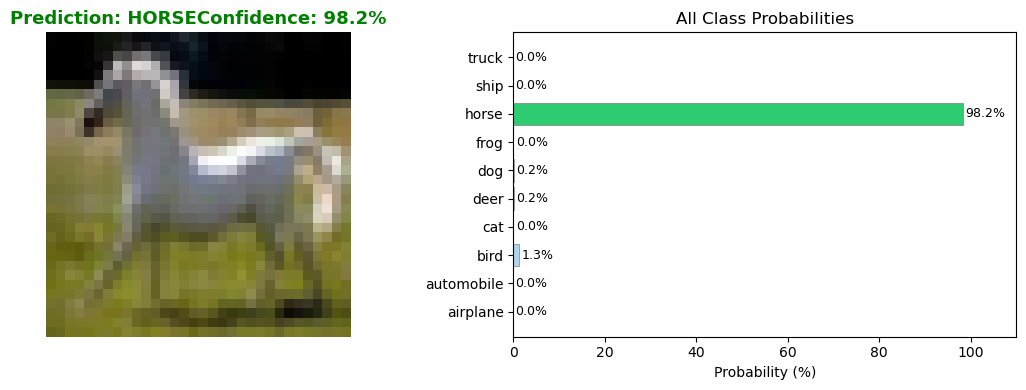

  True label : horse         Predicted : horse         Confidence : 98.2%  ✅

Got 5 / 6 correct in this random sample.


In [31]:
# ── Test the pipeline on 6 random test images ────────────────────────────────
# Pick the right test array (32px or 96px depending on best model)
if best_img_size == 96:
    test_images_for_inference = x_test_96
else:
    test_images_for_inference = x_test_norm

# Pick 6 random indices
random_indices = np.random.choice(len(test_images_for_inference), 6, replace=False)

print(f"🔍 Running inference with [{best_model_name}] on 6 random test images:")
print()

correct_count = 0

for idx in random_indices:
    raw_img    = (test_images_for_inference[idx] * 255).astype("uint8")  # back to 0-255 for display
    true_label = CLASS_NAMES[y_test[idx]]

    result = predict_single_image(raw_img, best_model, best_img_size, CLASS_NAMES)

    is_correct = result["predicted_class"] == true_label
    if is_correct:
        correct_count += 1
    symbol = "✅" if is_correct else "❌"

    print(f"  True label : {true_label:<12}  "
          f"Predicted : {result['predicted_class']:<12}  "
          f"Confidence : {result['confidence_pct']:.1f}%  {symbol}")

print()
print(f"Got {correct_count} / 6 correct in this random sample.")


---
## Step 12 — 📝 Conclusion

Congratulations on completing the project! 🎉

### What we built:

| Model | Type | Key idea |
|---|---|---|
| **SimpleCNN** | Custom | 3 conv blocks, dropout, batch norm |
| **DeepCNN Residual** | Custom | Skip connections for deeper training |
| **MobileNetV2** | Transfer Learning | Lightweight pre-trained model |
| **VGG16** | Transfer Learning | Classic deep pre-trained model |

### Key lessons:

1. **Always explore your data first** (EDA) — understand what you're working with.
2. **Normalise your images** — neural networks learn much faster with values in [0, 1].
3. **Data augmentation** creates variety and helps prevent overfitting.
4. **Deeper isn't always better** — skip connections help the signal flow through deep networks.
5. **Transfer learning is powerful** — pre-trained models give a huge head start.
6. **Callbacks are your friend** — EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint save time and improve results.
7. **Always evaluate on the test set last** — never use test data to make training decisions.




